In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from pydantic import BaseModel
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool
from langchain_huggingface import HuggingFaceEndpointEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from typing import Any
import requests
import math
import os
from dotenv import load_dotenv

C:\Users\Ndagano\AppData\Local\Temp\ipykernel_12476\1480388624.py:10: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


### Loading env variables

In [2]:
load_dotenv()

True

### Define LLM

In [3]:
model = ChatGroq(
    model="llama-3.3-70b-versatile"
)

embeddings_model = HuggingFaceEndpointEmbeddings(
    model="BAAI/bge-m3",
    provider="hf-inference",
)

In [4]:
query_embedding = embeddings_model.embed_query(
    "Qu'est-ce que l'intelligence artificielle ?"
)

print(len(query_embedding))
print(query_embedding[:5])

1024
[-0.035235047340393066, 0.008882617577910423, 0.017663629725575447, -0.011385096237063408, -0.015029721893370152]


In [5]:
loader = PyPDFLoader("../data/yc.pdf")
docs = loader.load()

In [6]:
docs

[Document(metadata={'producer': 'LibreOffice 25.2.3.2 (X86_64) / LibreOffice Community', 'creator': 'Writer', 'creationdate': '2026-07-09T09:58:13+00:00', 'author': 'python-docx', 'source': '../data/yc.pdf', 'total_pages': 26, 'page': 0, 'page_label': '1'}, page_content='Manuel Founder Tech & IA - approche inspirée YC\nMANUEL FOUNDER TECH & IA\nApprendre à créer, gérer, financer et scaler une entreprise \ntechnologique avec une approche inspirée des meilleurs principes \npublics de Y Combinator\nVersion autonome - 9 juillet 2026\nObjectif: donner à un fondateur tech/IA un système simple pour passer de l idée à une entreprise \ncapable de lever des fonds, croître vite, manager une équipe, maîtriser la technique, gérer les \nrisques et se préparer à une introduction en bourse.\nNote importante. Ce document n est pas un document officiel de Y Combinator et ne donne pas de \nconseil juridique, fiscal ou financier personnalisé. Il synthétise des principes publics et des pratiques \nreconnue

In [34]:
len(docs)

26

In [36]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

In [37]:
len(chunks)

58

In [40]:
vector_store = FAISS.from_documents(chunks, embeddings_model)
vector_store.save_local("faiss_index")

In [41]:
vector_store

In [45]:
retriever = vector_store.as_retriever(search_type="similarity", search_kweargs={"k": 4})

In [47]:
res = retriever.invoke("que fait yc")

In [48]:
res

[Document(id='05a40152-4b6d-42e7-8b9d-66e40cd3e2f1', metadata={'producer': 'LibreOffice 25.2.3.2 (X86_64) / LibreOffice Community', 'creator': 'Writer', 'creationdate': '2026-07-09T09:58:13+00:00', 'author': 'python-docx', 'source': '../data/yc.pdf', 'total_pages': 26, 'page': 1, 'page_label': '2'}, page_content='\uf0b7 17. Spécificités des entreprises IA\n\uf0b7 18. Se préparer à la cotation en bourse\n\uf0b7 19. Crises, pivots et survie\n\uf0b7 20. Plan d exécution 90 jours et templates\n1. La philosophie YC en une page\nYC répète une idée simple: une startup existe pour fabriquer quelque chose que les gens veulent vraiment. \nTout le reste - pitch deck, logo, bureaux, médias, financement - est secondaire tant que le produit ne résout \npas un problème réel pour un groupe précis d utilisateurs. YC est connu pour pousser les fondateurs à \naller vite, parler aux utilisateurs, mesurer la croissance et éviter les illusions. [S1] [S2]\nLes 12 principes à retenir\n\uf0b7 Make something pe

In [49]:
@tool
def rag_tool(query: str) -> str:
    """ 
        Retrieve relevant information from the PDF document.

        Use this tool when the user asks factual or conceptual questions
        that may be answered using the stored PDF documents.

        Args:
            query: the question or search query used to retrieve PDF content.
    """

    documents = retriever.invoke(query)

    if not documents:
        return "No relevant information was found in the PDF"

    formatted_documents = []

    for index, document in enumerate(documents, start=1):
        source = document.metadata.get("source", "Unknown source")
        page = document.metadata.get("page", "Unknown page")

        formatted_documents.append(
            f"Document {index}\n"
            f"Source: {source}\n"
            f"Page: {page}\n"
            f"Content: {document.page_content}"
        )


    return "\n\n".join(formatted_documents)




In [6]:
# Tools

search_tool = DuckDuckGoSearchRun()

@tool
def calculator(expression: str) -> str:
    """ 
        Useful for simple math calculations.
        Input should be a valid math expression.
        Example: 2 + 2, math.sqrt(16), 10 * 5
    """
    try:
        allowed = {
            "math": math,
            "abs": abs,
            "round": round,
            "min": min,
            "max": max,
            "sum": sum
        }

        result = eval(expression, {"__builtin__": {}}, allowed)
        return str(result)
    
    except Exception as e:
        return f"Calculation error: {str(e)}"


@tool
def get_stock_price(symbol: str) -> str:
    """ 
        Fetch latest stock price for a given symbol (e.g. 'AAPL', 'TSLA')
        using Alpha vantage with API key in the URL
    """

    api_key = os.getenv("ALPHA_VANTAGE_API_KEY")

    url = (
        "https://www.alphavantage.co/query"
        f"?function=GLOBAL_QUOTE&symbol={symbol.upper()}&apikey={api_key}"
    )

    r = requests.get(url)

    return r.json()

@tool
def get_weather(city: str) -> str:
    """
    Get the current weather for a city using the Weatherstack API.
    The input must contain only the city name.
    """

    api_key = os.getenv("WEATHERSTACK_API_KEY")

    if not api_key:
        return "Erreur : la variable WEATHERSTACK_API_KEY est absente."

    try:
        response = requests.get(
            "https://api.weatherstack.com/current",
            params={
                "access_key": api_key,
                "query": city,
            },
            timeout=15,
        )

        response.raise_for_status()
        data = response.json()

        if "current" not in data:
            error = data.get("error", {}).get(
                "info",
                "Réponse Weatherstack invalide.",
            )
            return f"Impossible d'obtenir la météo de {city} : {error}"

        location = data.get("location", {})
        current = data["current"]

        city_name = location.get("name", city)
        country = location.get("country", "")
        temperature = current.get("temperature")
        humidity = current.get("humidity")
        descriptions = current.get("weather_descriptions", [])
        description = descriptions[0] if descriptions else "indisponible"

        return (
            f"Météo actuelle à {city_name}, {country} : "
            f"{temperature} °C, {description}, "
            f"humidité de {humidity} %."
        )

    except requests.Timeout:
        return "La requête météo a expiré."

    except requests.RequestException as error:
        return f"Erreur réseau Weatherstack : {error}"

    except ValueError:
        return "Weatherstack a retourné une réponse JSON invalide."



In [50]:
# Make tool list

tools = [search_tool, calculator, get_stock_price, get_weather, rag_tool]

llm_with_tools = model.bind_tools(tools)

In [51]:

class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [ ]:
def chat_node(state: ChatState):
    
    messages = state["messages"]

    response = llm_with_tools.invoke(messages)

    return {'messages': [response]}

tool_node = ToolNode(tools)

In [54]:
checkpoint = MemorySaver()

graph = StateGraph(ChatState)


graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)

graph.add_edge(START, "chat_node")
graph.add_conditional_edges("chat_node", tools_condition)

graph.add_edge("tools", "chat_node")

workflow = graph.compile(checkpointer=checkpoint)

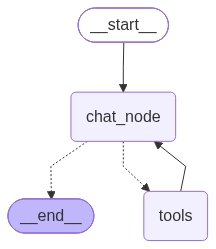

In [55]:
workflow

In [57]:
thread_id = "1"
initial_state = {
    "messages": [HumanMessage(content="C'est auoi la philosophie YC, selon de document")]
}
config = {'configurable': {'thread_id': thread_id}}
response = workflow.invoke(initial_state, config=config)
print(response["messages"][-1].content)

La philosophie YC, selon le document, est résumée en quelques points clés :

1. "Make something people want" : créer quelque chose que les gens veulent vraiment, plutôt que de créer quelque chose basé sur son ego.
2. Parler aux utilisateurs chaque semaine : les fondateurs doivent comprendre les besoins et les problèmes de leurs utilisateurs pour créer un produit qui répond à leurs besoins.
3. Lancer vite : un produit minimum viable (MVP) imparfait est préférable à un produit parfait qui n'est pas utilisé.
4. Se concentrer sur le client : les fondateurs doivent être obsédés par le client et son expérience, plutôt que par leurs propres opinions.
5. Livrer vite et réparer vite : les fondateurs doivent être capables de livrer leur produit rapidement et de réparer rapidement les problèmes qui surviennent.
6. Dire la vérité tôt : les fondateurs doivent être honnêtes et transparents avec leurs utilisateurs et leurs équipes.
7. Respecter les utilisateurs, les collègues et les contraintes réell

In [ ]:
thread_id = "1"
initial_state = {
    "messages": [HumanMessage(content="What is the weather in New york today?")]
}
config = {'configurable': {'thread_id': thread_id}}
response = workflow.invoke(initial_state, config=config)
print(response["messages"][-1].content)

In [28]:
thread_id = "1"
initial_state = {
    "messages": [HumanMessage(content="First find out the stock price of Apple, then calculate how much will it take to purchase 50 shares ?")]
}
config = {'configurable': {'thread_id': thread_id}}
response = workflow.invoke(initial_state, config=config)
print(response["messages"][-1].content)

The current stock price of Apple is $312.41. To purchase 50 shares, it will cost $15620.50.


In [24]:
thread_id = "1"
initial_state = {
    "messages": [HumanMessage(content="What is the new movie releases in 2026 ?")]
}
config = {'configurable': {'thread_id': thread_id}}
response = workflow.invoke(initial_state, config=config)
print(response["messages"][-1].content)

2 days ago - ↑ Renner, Brian D. "Everything You Need to Know About The Dreamer Cinderella Movie (2026): Dec. 13, 2025 - added new photos to the movie's photos gallery". Movie Insider. Retrieved January 12, 2026. ↑ Keyes, Rob (December 28, 2025). "33 Movies Releasing in 2026 Revealed in New Exclusive Images". 20 hours ago - Forbidden Fruits The Mummy Returns (Re-Release) She Dances They Will Kill You The AI Doc: Or How I Became an Apocaloptimist (Theaters) Alpha (Theaters) Fantasy Life (Theaters) Holy Days (Theaters) John Lilly and the Earth Coincidence Control Office (Theaters) Kontinental '25 (Theaters) A Magnificent Life (Theaters) Mike & Nick & Nick & Alice (Hulu) Our Hero, Balthazar (Theaters) Refuge (VOD) Stand by Me (Re-Release) Yes (Theaters) You're Dating a Narcissist! (Theaters) April 2026 · The Super Mario Galaxy Movie · The Drama The Blue Trail (Theaters) A Great Awakening (Theaters) Pizza Movie (Hu 4 days ago - Shawn, Marlon, and older brother Keenen Ivory co-wrote the film